## Setup

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

load_dotenv()
url = (
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME_DWH')}"
)
engine = create_engine(url)

def q(sql):
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

OUT_DIR = Path("../docs/clustering")
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
print("Setup OK ✓")

Setup OK ✓


## Cargar datos desde customer_360

In [2]:
df = q("""
    SELECT 
        customer_sk,
        customer_id_nk,
        full_name,
        num_orders,
        total_units,
        avg_order_value,
        net_revenue_after_returns,
        gross_margin,
        customer_lifespan_days,
        days_since_last_order,
        return_rate,
        is_one_shot,
        is_recurrent,
        is_churned,
        cltv_historic,
        rfm_segment,
        churn_risk_level
    FROM marts.customer_360;
""")
print(f"Total clientes: {len(df)}")
print(f"  - One-shot: {df['is_one_shot'].sum()}")
print(f"  - Recurrent: {df['is_recurrent'].sum()}")
df.head()

Total clientes: 5750
  - One-shot: 5000
  - Recurrent: 750


,customer_sk,customer_id_nk,full_name,num_orders,total_units,avg_order_value,net_revenue_after_returns,gross_margin,customer_lifespan_days,days_since_last_order,return_rate,is_one_shot,is_recurrent,is_churned,cltv_historic,rfm_segment,churn_risk_level
0,1,1,Marta Ruiz García,22,103,533.30,"11,502.66","4,688.48",1920,90,0.02,False,True,False,"4,596.52",Champions,Low
1,2,2,Alejandro López López,24,122,531.01,"12,429.59","5,098.08",2068,61,0.05,False,True,False,"4,972.20",Champions,Low
2,3,3,Alejandro López Álvarez,24,143,827.60,"19,416.56","7,945.44",1908,53,0.04,False,True,False,"7,767.04",Champions,Low
3,4,4,Javier Ruiz Fernández,10,61,820.38,"7,993.78","3,281.72",2063,18,0.03,False,True,False,"3,197.72",Champions,Low
4,5,5,David Gómez Pérez,22,108,497.18,"10,578.18","4,375.48",2091,23,0.04,False,True,False,"4,231.52",Champions,Low


## Definir features

In [3]:
FEATURES = [
    'num_orders',
    'total_units',
    'avg_order_value',
    'net_revenue_after_returns',
    'gross_margin',
    'customer_lifespan_days',
    'days_since_last_order',
    'return_rate',
]
print(f"Features: {len(FEATURES)}")

# Estadísticas previas al escalado
df[FEATURES].describe().round(2)

Features: 8


,num_orders,total_units,avg_order_value,net_revenue_after_returns,gross_margin,customer_lifespan_days,days_since_last_order,return_rate
count,"5,750.00","5,750.00","5,750.00","5,750.00","5,750.00","5,750.00","5,750.00","5,750.00"
mean,3.48,14.22,221.09,"1,635.19",673.34,256.22,673.46,0.07
std,6.59,34.40,205.22,"3,989.07","1,636.07",664.01,601.07,0.24
min,1.00,1.00,19.99,-179.99,8.00,0.00,0.00,0.00
25%,1.00,1.00,79.80,59.99,31.92,0.00,92.00,0.00
50%,1.00,1.00,149.90,129.99,59.96,0.00,421.00,0.00
75%,1.00,2.00,299.99,299.99,120.00,0.00,"1,299.75",0.00
max,34.00,195.00,"1,199.97","23,932.15","9,969.40","2,183.00","1,824.00",2.00


# PARTE A — Clustering sobre TODOS los clientes (5.750)

## Escalado y PCA (todos)

Varianza explicada por componente:
  PC1: 70.30%  (acumulada: 70.30%)
  PC2: 12.43%  (acumulada: 82.73%)
  PC3: 10.70%  (acumulada: 93.43%)
  PC4:  5.66%  (acumulada: 99.09%)
  PC5:  0.68%  (acumulada: 99.76%)
  PC6:  0.16%  (acumulada: 99.93%)
  PC7:  0.07%  (acumulada: 100.00%)
  PC8:  0.00%  (acumulada: 100.00%)


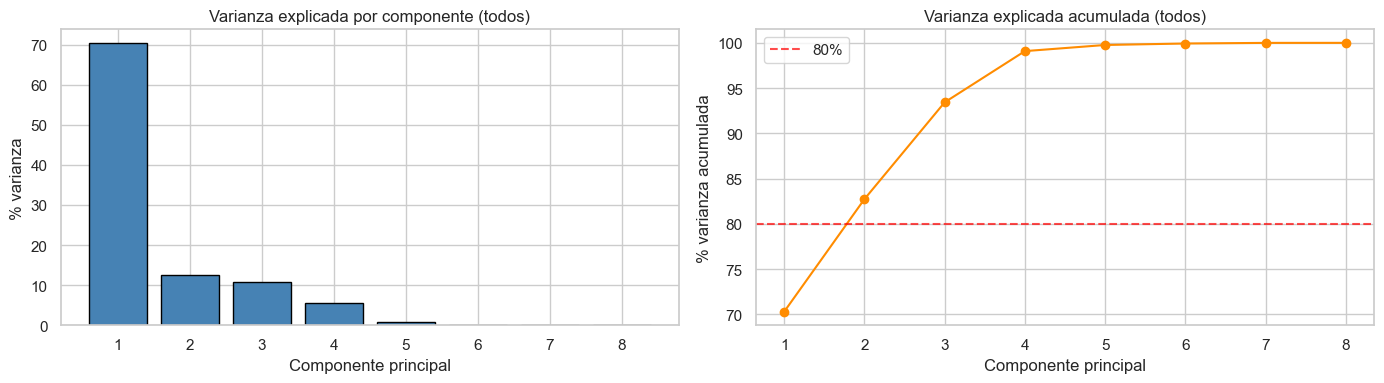

In [4]:
X_all = df[FEATURES].values
scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all)

# PCA con todas las componentes
pca_all = PCA(random_state=RANDOM_STATE)
X_all_pca = pca_all.fit_transform(X_all_scaled)

# Varianza explicada
var_exp = pca_all.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

print("Varianza explicada por componente:")
for i, (v, c) in enumerate(zip(var_exp, var_cum), 1):
    print(f"  PC{i}: {v*100:5.2f}%  (acumulada: {c*100:5.2f}%)")

# Visualización del scree plot
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(range(1, len(var_exp)+1), var_exp*100, color='steelblue', edgecolor='black')
ax[0].set_title('Varianza explicada por componente (todos)')
ax[0].set_xlabel('Componente principal')
ax[0].set_ylabel('% varianza')

ax[1].plot(range(1, len(var_cum)+1), var_cum*100, marker='o', color='darkorange')
ax[1].axhline(80, color='red', linestyle='--', alpha=0.7, label='80%')
ax[1].set_title('Varianza explicada acumulada (todos)')
ax[1].set_xlabel('Componente principal')
ax[1].set_ylabel('% varianza acumulada')
ax[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "10_pca_scree_all.png", dpi=120, bbox_inches='tight')
plt.show()

## Cargas (loadings) de los 2 primeros PCs (todos)

Loadings de los primeros 3 PCs:
                            PC1   PC2  PC3
num_orders                 0.41  0.03 0.06
total_units                0.42  0.02 0.07
avg_order_value            0.32 -0.04 0.11
net_revenue_after_returns  0.42  0.01 0.07
gross_margin               0.42  0.02 0.07
customer_lifespan_days     0.41  0.02 0.05
days_since_last_order     -0.17 -0.03 0.98
return_rate               -0.04  1.00 0.03


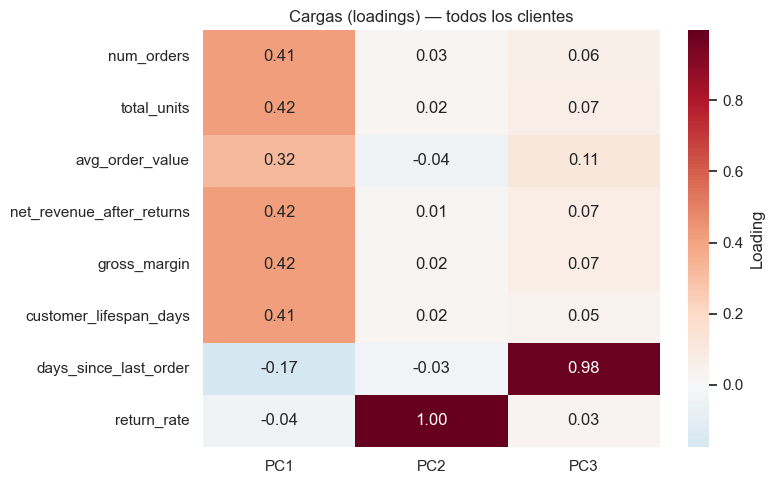

In [5]:
# ¿Qué representa cada componente principal?
loadings = pd.DataFrame(
    pca_all.components_[:3].T,
    columns=['PC1','PC2','PC3'],
    index=FEATURES
).round(3)
print("Loadings de los primeros 3 PCs:")
print(loadings)

# Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label': 'Loading'})
ax.set_title('Cargas (loadings) — todos los clientes')
plt.tight_layout()
plt.savefig(FIG_DIR / "11_pca_loadings_all.png", dpi=120, bbox_inches='tight')
plt.show()

## Determinar K óptimo (todos)

Usando 2 componentes (>=80% varianza)


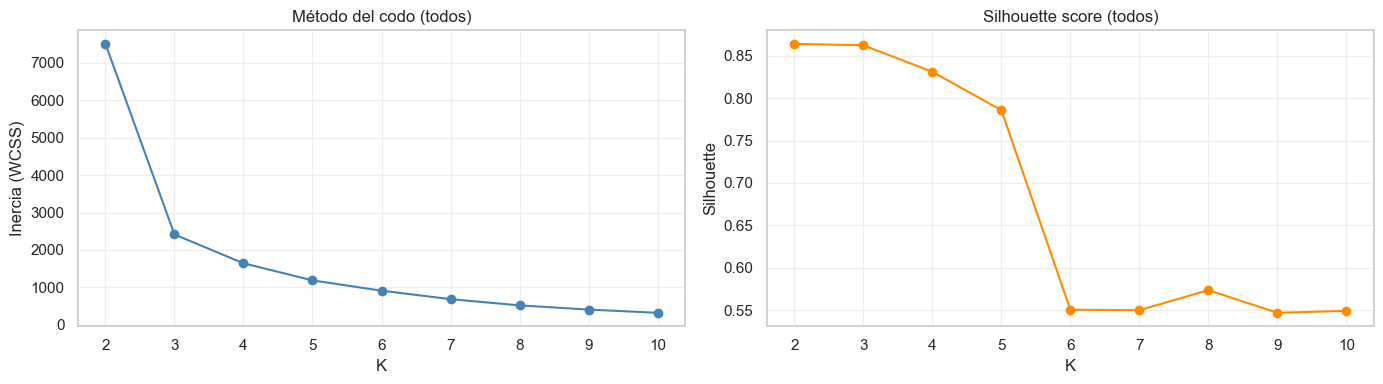


Resultados:
  K=2: inercia=    7505  silhouette=0.864
  K=3: inercia=    2414  silhouette=0.862
  K=4: inercia=    1644  silhouette=0.831
  K=5: inercia=    1187  silhouette=0.786
  K=6: inercia=     913  silhouette=0.551
  K=7: inercia=     686  silhouette=0.550
  K=8: inercia=     520  silhouette=0.574
  K=9: inercia=     408  silhouette=0.547
  K=10: inercia=     321  silhouette=0.549


In [6]:
ks = range(2, 11)
inertias = []
silhouettes = []

# Usamos los primeros componentes que explican >=80% de varianza para clustering
n_pcs_all = int((var_cum >= 0.80).argmax() + 1)
print(f"Usando {n_pcs_all} componentes (>=80% varianza)")
X_all_red = X_all_pca[:, :n_pcs_all]

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_all_red)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_all_red, labels))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(list(ks), inertias, marker='o', color='steelblue')
ax[0].set_title('Método del codo (todos)')
ax[0].set_xlabel('K')
ax[0].set_ylabel('Inercia (WCSS)')
ax[0].grid(True, alpha=0.3)

ax[1].plot(list(ks), silhouettes, marker='o', color='darkorange')
ax[1].set_title('Silhouette score (todos)')
ax[1].set_xlabel('K')
ax[1].set_ylabel('Silhouette')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "12_kmeans_eval_all.png", dpi=120, bbox_inches='tight')
plt.show()

print("\nResultados:")
for k, iner, sil in zip(ks, inertias, silhouettes):
    print(f"  K={k}: inercia={iner:8.0f}  silhouette={sil:.3f}")

## Aplicar K-Means con K elegido (todos)

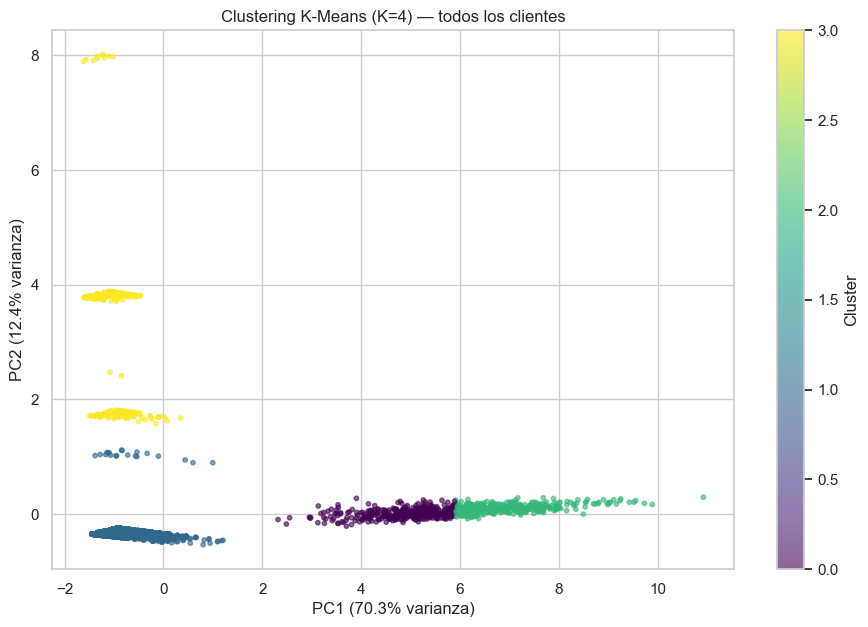


Perfil de cada cluster:


,num_orders,total_units,avg_order_value,net_revenue_after_returns,gross_margin,customer_lifespan_days,days_since_last_order,return_rate,cltv_historic,n_clientes
cluster_all,,,,,,,,,,
0,16.88,80.85,550.68,"8,973.70","3,683.19","1,929.50",144.37,0.02,"3,589.69",363
1,1.00,1.36,167.30,166.81,66.93,0.00,756.11,0.00,66.73,4580
2,22.93,117.98,625.12,"13,870.38","5,692.22","1,997.08",96.21,0.03,"5,548.42",387
3,1.00,1.31,150.40,31.20,60.17,0.00,761.31,0.88,12.48,420


In [7]:
# Mira el output anterior. Probablemente el codo está en K=3 o K=4.
# Cambia K_ALL si tu silhouette/codo sugiere otro valor
K_ALL = 4  # AJUSTAR según resultados

km_all = KMeans(n_clusters=K_ALL, random_state=RANDOM_STATE, n_init=10)
df['cluster_all'] = km_all.fit_predict(X_all_red)

# Visualización en 2D (PC1 vs PC2)
fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(X_all_pca[:, 0], X_all_pca[:, 1], 
                     c=df['cluster_all'], cmap='viridis', s=10, alpha=0.6)
plt.colorbar(scatter, label='Cluster')
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% varianza)')
ax.set_title(f'Clustering K-Means (K={K_ALL}) — todos los clientes')
plt.savefig(FIG_DIR / "13_clusters_all_2d.png", dpi=120, bbox_inches='tight')
plt.show()

# Caracterización de cada cluster
profile_all = df.groupby('cluster_all')[FEATURES + ['cltv_historic']].mean().round(2)
profile_all['n_clientes'] = df.groupby('cluster_all').size()
print("\nPerfil de cada cluster:")
profile_all

## Cruce con RFM (todos)

Cruce cluster_all vs rfm_segment:
rfm_segment  At Risk  Cant Lose Them  Champions  Hibernating  Lost  \
cluster_all                                                          
0                  0               0        342            0     0   
1                248             474        111          497   383   
2                  0               0        379            0     0   
3                  4              14          1            6    54   

rfm_segment  Loyal Customers  New Customers  Others  Potential Loyalists  
cluster_all                                                               
0                         21              0       0                    0  
1                        297            909    1389                  272  
2                          8              0       0                    0  
3                          7             66     257                   11  


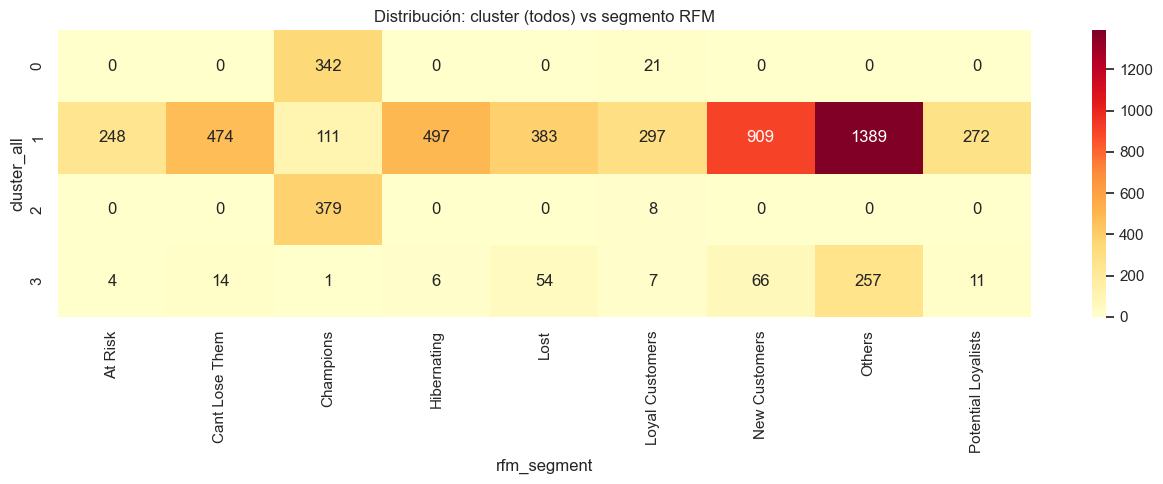

In [8]:
ct_all = pd.crosstab(df['cluster_all'], df['rfm_segment'])
print("Cruce cluster_all vs rfm_segment:")
print(ct_all)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(ct_all, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('Distribución: cluster (todos) vs segmento RFM')
plt.tight_layout()
plt.savefig(FIG_DIR / "14_clusters_vs_rfm_all.png", dpi=120, bbox_inches='tight')
plt.show()

# PARTE B — Clustering solo sobre RECURRENTES (750)

## Subset y reescalado

In [9]:
df_rec = df[df['is_recurrent']].copy().reset_index(drop=True)
print(f"Clientes recurrentes: {len(df_rec)}")

X_rec = df_rec[FEATURES].values
scaler_rec = StandardScaler()
X_rec_scaled = scaler_rec.fit_transform(X_rec)

# PCA
pca_rec = PCA(random_state=RANDOM_STATE)
X_rec_pca = pca_rec.fit_transform(X_rec_scaled)

var_exp_r = pca_rec.explained_variance_ratio_
var_cum_r = np.cumsum(var_exp_r)

print("Varianza explicada (recurrentes):")
for i, (v, c) in enumerate(zip(var_exp_r, var_cum_r), 1):
    print(f"  PC{i}: {v*100:5.2f}%  (acumulada: {c*100:5.2f}%)")

Clientes recurrentes: 750
Varianza explicada (recurrentes):
  PC1: 50.72%  (acumulada: 50.72%)
  PC2: 20.30%  (acumulada: 71.02%)
  PC3: 12.56%  (acumulada: 83.58%)
  PC4: 12.17%  (acumulada: 95.75%)
  PC5:  3.04%  (acumulada: 98.78%)
  PC6:  1.04%  (acumulada: 99.82%)
  PC7:  0.17%  (acumulada: 99.99%)
  PC8:  0.01%  (acumulada: 100.00%)


## PCA scree y loadings (recurrentes)

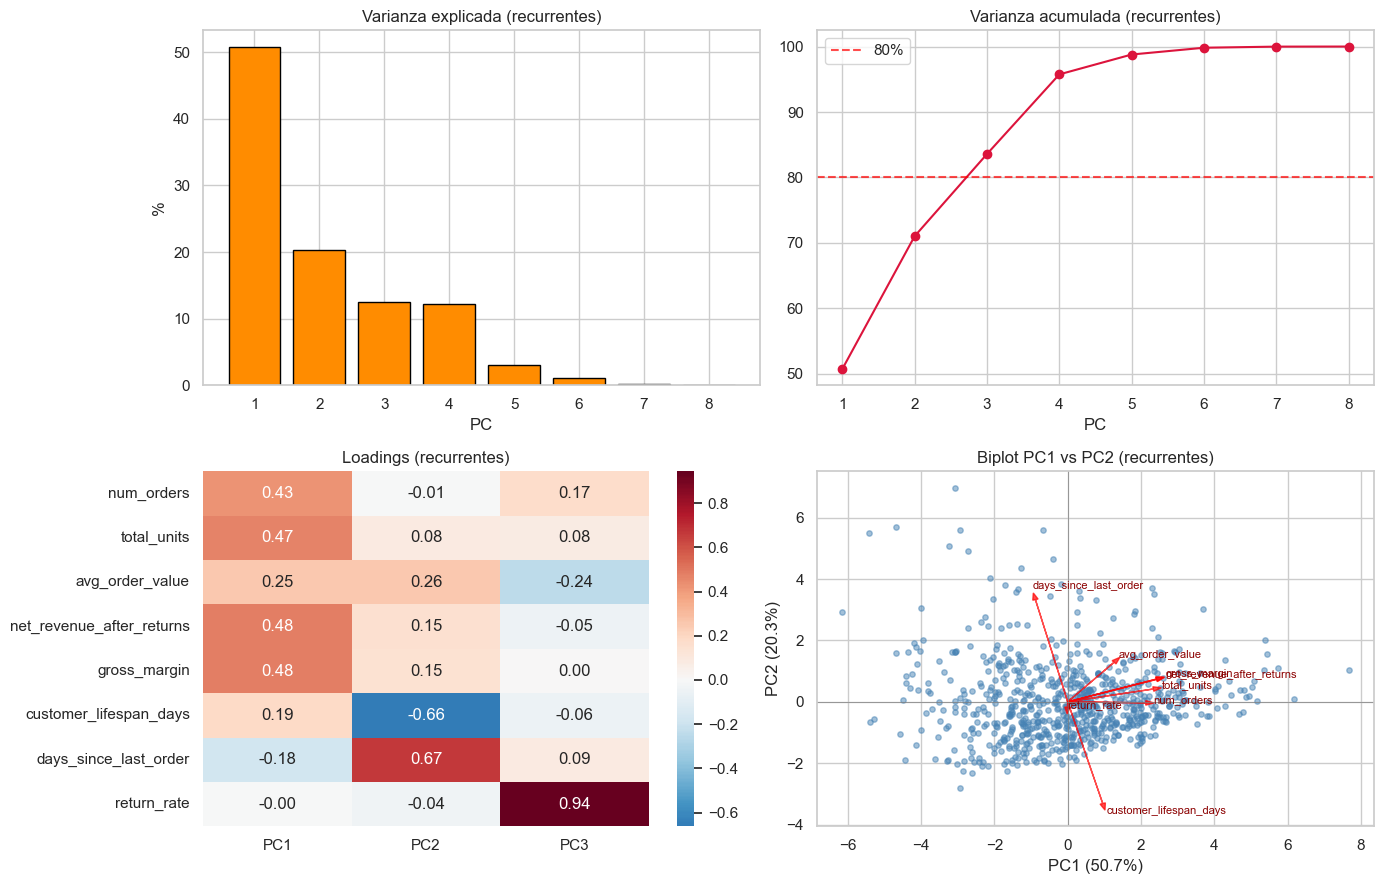


Loadings:
                            PC1   PC2   PC3
num_orders                 0.43 -0.01  0.17
total_units                0.47  0.08  0.08
avg_order_value            0.25  0.26 -0.24
net_revenue_after_returns  0.48  0.15 -0.05
gross_margin               0.48  0.15  0.00
customer_lifespan_days     0.19 -0.66 -0.06
days_since_last_order     -0.18  0.67  0.09
return_rate               -0.00 -0.04  0.94


In [10]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

ax[0,0].bar(range(1, len(var_exp_r)+1), var_exp_r*100, color='darkorange', edgecolor='black')
ax[0,0].set_title('Varianza explicada (recurrentes)')
ax[0,0].set_xlabel('PC')
ax[0,0].set_ylabel('%')

ax[0,1].plot(range(1, len(var_cum_r)+1), var_cum_r*100, marker='o', color='crimson')
ax[0,1].axhline(80, color='red', linestyle='--', alpha=0.7, label='80%')
ax[0,1].set_title('Varianza acumulada (recurrentes)')
ax[0,1].set_xlabel('PC')
ax[0,1].legend()

# Loadings
loadings_r = pd.DataFrame(
    pca_rec.components_[:3].T, columns=['PC1','PC2','PC3'], index=FEATURES
).round(3)
sns.heatmap(loadings_r, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax[1,0])
ax[1,0].set_title('Loadings (recurrentes)')

# Biplot simple
ax[1,1].scatter(X_rec_pca[:,0], X_rec_pca[:,1], s=15, alpha=0.5, color='steelblue')
for i, feat in enumerate(FEATURES):
    ax[1,1].arrow(0, 0, pca_rec.components_[0,i]*5, pca_rec.components_[1,i]*5,
                  head_width=0.15, color='red', alpha=0.7)
    ax[1,1].text(pca_rec.components_[0,i]*5.5, pca_rec.components_[1,i]*5.5, feat,
                 fontsize=8, color='darkred')
ax[1,1].set_title('Biplot PC1 vs PC2 (recurrentes)')
ax[1,1].set_xlabel(f'PC1 ({var_exp_r[0]*100:.1f}%)')
ax[1,1].set_ylabel(f'PC2 ({var_exp_r[1]*100:.1f}%)')
ax[1,1].axhline(0, color='gray', linewidth=0.5)
ax[1,1].axvline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.savefig(FIG_DIR / "15_pca_recurrentes.png", dpi=120, bbox_inches='tight')
plt.show()

print("\nLoadings:")
print(loadings_r)

## K óptimo (recurrentes)

Usando 3 componentes (>=80% varianza)


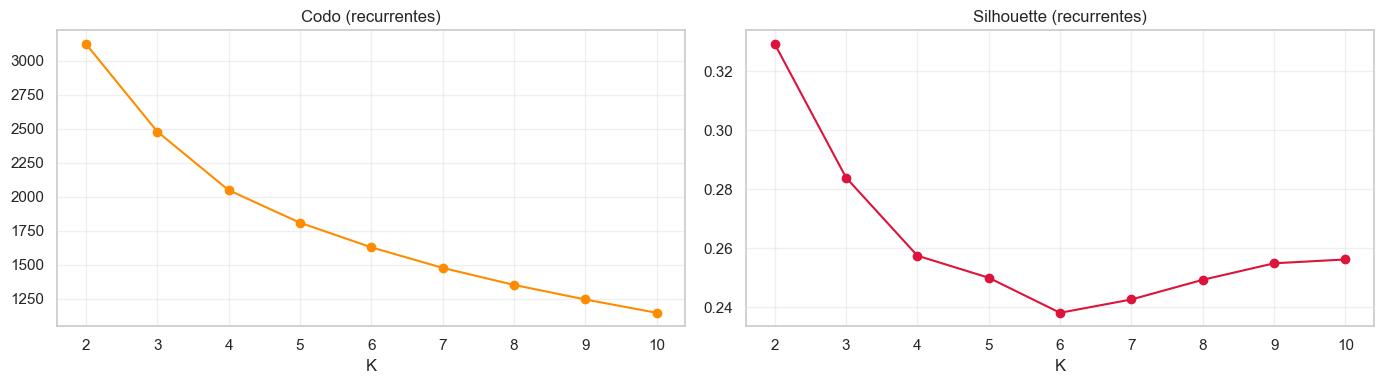


Resultados:
  K=2: inercia=    3125  silhouette=0.329
  K=3: inercia=    2480  silhouette=0.284
  K=4: inercia=    2048  silhouette=0.257
  K=5: inercia=    1809  silhouette=0.250
  K=6: inercia=    1627  silhouette=0.238
  K=7: inercia=    1476  silhouette=0.243
  K=8: inercia=    1350  silhouette=0.249
  K=9: inercia=    1243  silhouette=0.255
  K=10: inercia=    1145  silhouette=0.256


In [11]:
n_pcs_rec = int((var_cum_r >= 0.80).argmax() + 1)
print(f"Usando {n_pcs_rec} componentes (>=80% varianza)")
X_rec_red = X_rec_pca[:, :n_pcs_rec]

ks = range(2, 11)
inertias_r = []
silhouettes_r = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_rec_red)
    inertias_r.append(km.inertia_)
    silhouettes_r.append(silhouette_score(X_rec_red, labels))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(list(ks), inertias_r, marker='o', color='darkorange')
ax[0].set_title('Codo (recurrentes)'); ax[0].set_xlabel('K'); ax[0].grid(alpha=0.3)
ax[1].plot(list(ks), silhouettes_r, marker='o', color='crimson')
ax[1].set_title('Silhouette (recurrentes)'); ax[1].set_xlabel('K'); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "16_kmeans_eval_recurrentes.png", dpi=120, bbox_inches='tight')
plt.show()

print("\nResultados:")
for k, iner, sil in zip(ks, inertias_r, silhouettes_r):
    print(f"  K={k}: inercia={iner:8.0f}  silhouette={sil:.3f}")

## K-Means final sobre recurrentes

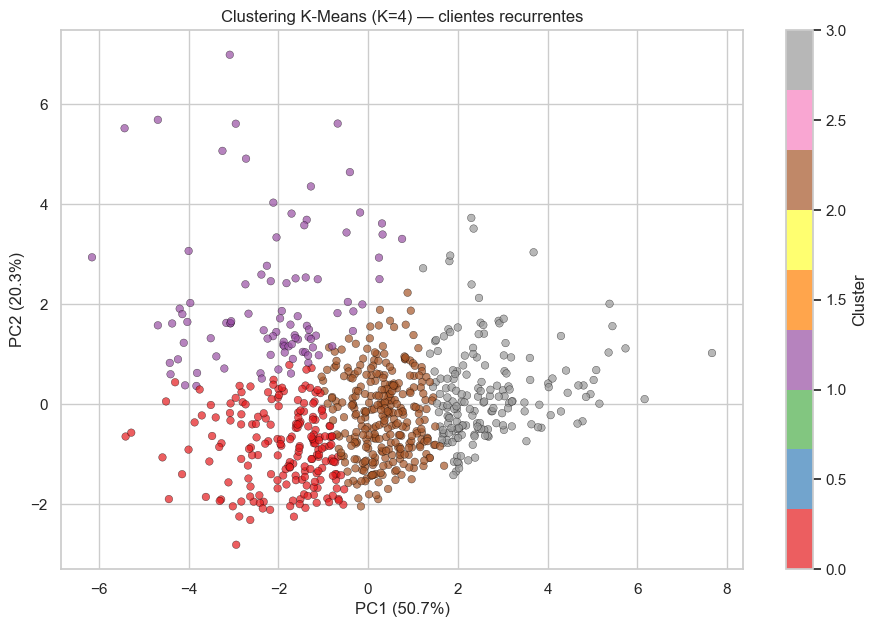


Perfil de cada cluster (recurrentes):


,num_orders,total_units,avg_order_value,net_revenue_after_returns,gross_margin,customer_lifespan_days,days_since_last_order,return_rate,cltv_historic,n_clientes
cluster_rec,,,,,,,,,,
0,16.24,76.41,528.93,"8,253.90","3,392.57","2,000.59",87.69,0.02,"3,301.76",192
1,16.50,80.15,574.57,"9,170.63","3,768.36","1,692.23",348.86,0.03,"3,668.43",92
2,20.70,103.36,593.97,"11,852.73","4,860.38","1,993.00",89.69,0.02,"4,741.35",293
3,24.85,131.10,655.30,"15,745.62","6,460.90","2,020.42",83.42,0.02,"6,298.53",173


In [12]:
# AJUSTAR si el silhouette/codo sugiere otro valor
K_REC = 4

km_rec = KMeans(n_clusters=K_REC, random_state=RANDOM_STATE, n_init=10)
df_rec['cluster_rec'] = km_rec.fit_predict(X_rec_red)

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(X_rec_pca[:, 0], X_rec_pca[:, 1], 
                     c=df_rec['cluster_rec'], cmap='Set1', s=30, alpha=0.7,
                     edgecolor='black', linewidth=0.3)
plt.colorbar(scatter, label='Cluster')
ax.set_xlabel(f'PC1 ({var_exp_r[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_exp_r[1]*100:.1f}%)')
ax.set_title(f'Clustering K-Means (K={K_REC}) — clientes recurrentes')
plt.savefig(FIG_DIR / "17_clusters_recurrentes_2d.png", dpi=120, bbox_inches='tight')
plt.show()

# Perfil
profile_rec = df_rec.groupby('cluster_rec')[FEATURES + ['cltv_historic']].mean().round(2)
profile_rec['n_clientes'] = df_rec.groupby('cluster_rec').size()
print("\nPerfil de cada cluster (recurrentes):")
profile_rec

## Cruce cluster recurrentes vs RFM

Cruce cluster_rec vs rfm_segment:
rfm_segment  Champions  Loyal Customers
cluster_rec                            
0                  192                0
1                   64               28
2                  293                0
3                  172                1


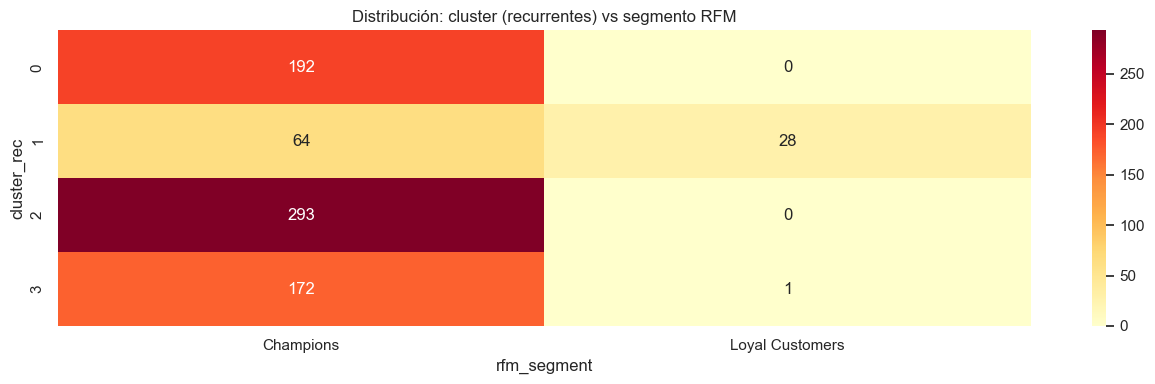

In [13]:
ct_rec = pd.crosstab(df_rec['cluster_rec'], df_rec['rfm_segment'])
print("Cruce cluster_rec vs rfm_segment:")
print(ct_rec)

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(ct_rec, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('Distribución: cluster (recurrentes) vs segmento RFM')
plt.tight_layout()
plt.savefig(FIG_DIR / "18_clusters_vs_rfm_recurrentes.png", dpi=120, bbox_inches='tight')
plt.show()

## Asignar nombres a los clusters (interpretación)

In [14]:
# A partir del perfil, asigna nombres descriptivos.
# Ejemplo (AJUSTAR según vuestros resultados):
#   Cluster con mayor cltv_historic + alto num_orders → "VIPs leales"
#   Cluster con cltv medio y recencia alta → "Activos consolidados"
#   Cluster con recencia muy alta (mucho días sin comprar) → "Durmiendo"
#   Cluster con baja frecuencia → "Recurrentes ocasionales"

# Vamos a ver el ranking
print("Para nombrar los clusters (recurrentes), mira los siguientes valores:")
for col in ['num_orders', 'cltv_historic', 'days_since_last_order', 'avg_order_value']:
    print(f"\n{col} medio por cluster:")
    print(df_rec.groupby('cluster_rec')[col].mean().sort_values(ascending=False))

Para nombrar los clusters (recurrentes), mira los siguientes valores:

num_orders medio por cluster:
cluster_rec
3   24.85
2   20.70
1   16.50
0   16.24
Name: num_orders, dtype: float64

cltv_historic medio por cluster:
cluster_rec
3   6,298.53
2   4,741.35
1   3,668.43
0   3,301.76
Name: cltv_historic, dtype: float64

days_since_last_order medio por cluster:
cluster_rec
1   348.86
2    89.69
0    87.69
3    83.42
Name: days_since_last_order, dtype: float64

avg_order_value medio por cluster:
cluster_rec
3   655.30
2   593.97
1   574.57
0   528.93
Name: avg_order_value, dtype: float64


## Guardar resultados a marts

In [15]:
# Vamos a guardar las asignaciones de cluster en marts.customer_360
# Para que cualquier query SQL pueda usarlas
ASSIGN_NAMES_REC = {
    # Rellena después de ver la celda 14
    # 0: 'VIPs leales',
    # 1: 'Activos consolidados',
    # 2: 'Durmiendo',
    # 3: 'Recurrentes ocasionales',
}

# Por ahora guardamos los IDs numéricos
df_clusters = df[['customer_sk', 'cluster_all']].copy()
df_clusters = df_clusters.merge(
    df_rec[['customer_sk', 'cluster_rec']], on='customer_sk', how='left'
)

print(f"Clientes con cluster_all asignado: {df_clusters['cluster_all'].notna().sum()}")
print(f"Clientes con cluster_rec asignado: {df_clusters['cluster_rec'].notna().sum()}")
df_clusters.head()

# Guardamos a CSV (luego veremos cómo añadirlo a customer_360)
df_clusters.to_csv(OUT_DIR / "cluster_assignments.csv", index=False)
print(f"\nGuardado en {OUT_DIR / 'cluster_assignments.csv'}")

Clientes con cluster_all asignado: 5750
Clientes con cluster_rec asignado: 750

Guardado en ..\docs\clustering\cluster_assignments.csv
